In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import statsmodels
import joblib

from prophet import Prophet

import tensorflow as tf

import sys

print("Everything imported successfully!")
print()
print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

Everything imported successfully!

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Pandas: 3.0.6
NumPy: 2.4.6
TensorFlow: 2.21.0


In [15]:
import os

file_path = r"D:\Crude_Oil_Forcasting_Model\data\raw\EIA_petroleum_spot_prices.xls.xls"

print("Dataset path:")
print(file_path)

print("\nFile exists:", os.path.exists(file_path))

Dataset path:
D:\Crude_Oil_Forcasting_Model\data\raw\EIA_petroleum_spot_prices.xls.xls

File exists: True


In [16]:
raw = pd.read_excel(
    file_path,
    sheet_name=0,
    header=None
)

print("Raw dataset shape:", raw.shape)

raw.head(15)

Raw dataset shape: (22, 7)


,0,1,2,3,4,5,6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Workbook Contents,NaN,NaN,NaN,NaN,NaN
2,NaN,Spot Prices for Crude Oil and Petroleum Products,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Click worksheet name or tab at bottom for data,NaN,NaN,NaN,NaN,NaN
5,NaN,Worksheet Name,Description,# Of Series,Frequency,Latest Data for,NaN
6,NaN,Data 1,Crude Oil,2,Daily,9/22/2026,1/2/1986
7,NaN,Data 2,Conventional Gasoline,2,Daily,9/22/2026,6/2/1986
8,NaN,Data 3,RBOB Regular Gasoline,1,Daily,9/22/2026,3/17/2003
9,NaN,Data 4,No. 2 Heating Oil,1,Daily,9/22/2026,6/2/1986


In [17]:
excel_file = pd.ExcelFile(file_path)

print("Available worksheets:")
for i, sheet in enumerate(excel_file.sheet_names):
    print(i, ":", sheet)

Available worksheets:
0 : Contents
1 : Data 1
2 : Data 2
3 : Data 3
4 : Data 4
5 : Data 5
6 : Data 6
7 : Data 7


In [18]:
for sheet in excel_file.sheet_names:
    print("\n" + "=" * 60)
    print("SHEET:", sheet)
    print("=" * 60)
    
    temp = pd.read_excel(
        file_path,
        sheet_name=sheet,
        header=None
    )
    
    print("Shape:", temp.shape)
    print(temp.head(8).to_string())


SHEET: Contents
Shape: (22, 7)
    0                                                 1                      2            3          4                5         6
0 NaN                                               NaN                    NaN          NaN        NaN              NaN       NaN
1 NaN                                 Workbook Contents                    NaN          NaN        NaN              NaN       NaN
2 NaN  Spot Prices for Crude Oil and Petroleum Products                    NaN          NaN        NaN              NaN       NaN
3 NaN                                               NaN                    NaN          NaN        NaN              NaN       NaN
4 NaN    Click worksheet name or tab at bottom for data                    NaN          NaN        NaN              NaN       NaN
5 NaN                                    Worksheet Name            Description  # Of Series  Frequency  Latest Data for       NaN
6 NaN                                            Data 1   

In [19]:
crude = pd.read_excel(
    file_path,
    sheet_name="Data 1",
    skiprows=2
)

crude = crude.iloc[:, :3]

crude.columns = [
    "Date",
    "WTI",
    "Brent"
]

crude["Date"] = pd.to_datetime(
    crude["Date"],
    errors="coerce"
)

crude["WTI"] = pd.to_numeric(
    crude["WTI"],
    errors="coerce"
)

crude["Brent"] = pd.to_numeric(
    crude["Brent"],
    errors="coerce"
)

crude = crude.dropna(
    subset=["Date"]
)

crude.head()

,Date,WTI,Brent
0,1986-01-02,25.56,NaN
1,1986-01-03,26.00,NaN
2,1986-01-06,26.53,NaN
3,1986-01-07,25.85,NaN
4,1986-01-08,25.87,NaN


In [20]:
gasoline = pd.read_excel(
    file_path,
    sheet_name="Data 2",
    skiprows=2
)

gasoline = gasoline.iloc[:, :3]

gasoline.columns = [
    "Date",
    "Gasoline_NY",
    "Gasoline_Gulf"
]

gasoline["Date"] = pd.to_datetime(
    gasoline["Date"],
    errors="coerce"
)

gasoline["Gasoline_NY"] = pd.to_numeric(
    gasoline["Gasoline_NY"],
    errors="coerce"
)

gasoline["Gasoline_Gulf"] = pd.to_numeric(
    gasoline["Gasoline_Gulf"],
    errors="coerce"
)

gasoline = gasoline.dropna(
    subset=["Date"]
)

gasoline.head()

,Date,Gasoline_NY,Gasoline_Gulf
0,1986-06-02,0.468,0.445
1,1986-06-03,0.436,0.418
2,1986-06-04,0.418,0.398
3,1986-06-05,0.431,0.415
4,1986-06-06,0.421,0.403


In [21]:
diesel = pd.read_excel(
    file_path,
    sheet_name="Data 5",
    skiprows=2
)

diesel = diesel.iloc[:, :4]

diesel.columns = [
    "Date",
    "Diesel_NY",
    "Diesel_Gulf",
    "Diesel_LA"
]

diesel["Date"] = pd.to_datetime(
    diesel["Date"],
    errors="coerce"
)

for column in [
    "Diesel_NY",
    "Diesel_Gulf",
    "Diesel_LA"
]:
    diesel[column] = pd.to_numeric(
        diesel[column],
        errors="coerce"
    )

diesel = diesel.dropna(
    subset=["Date"]
)

diesel.head()

,Date,Diesel_NY,Diesel_Gulf,Diesel_LA
0,1996-04-17,NaN,NaN,0.905
1,1996-04-18,NaN,NaN,0.930
2,1996-04-19,NaN,NaN,0.940
3,1996-04-22,NaN,NaN,0.960
4,1996-04-23,NaN,NaN,0.955


In [22]:
jet = pd.read_excel(
    file_path,
    sheet_name="Data 6",
    skiprows=2
)

jet = jet.iloc[:, :2]

jet.columns = [
    "Date",
    "JetFuel"
]

jet["Date"] = pd.to_datetime(
    jet["Date"],
    errors="coerce"
)

jet["JetFuel"] = pd.to_numeric(
    jet["JetFuel"],
    errors="coerce"
)

jet = jet.dropna(
    subset=["Date"]
)

jet.head()

,Date,JetFuel
0,1990-04-02,0.550
1,1990-04-03,0.555
2,1990-04-04,0.560
3,1990-04-05,0.540
4,1990-04-06,0.536


In [23]:
crude_selected = crude[
    [
        "Date",
        "WTI",
        "Brent"
    ]
].copy()

gasoline_selected = gasoline[
    [
        "Date",
        "Gasoline_NY"
    ]
].copy()

diesel_selected = diesel[
    [
        "Date",
        "Diesel_NY"
    ]
].copy()

jet_selected = jet[
    [
        "Date",
        "JetFuel"
    ]
].copy()

In [27]:
data = crude_selected.merge(
    gasoline_selected,
    on="Date",
    how="inner"
)

data = data.merge(
    diesel_selected,
    on="Date",
    how="inner"
)

data = data.merge(
    jet_selected,
    on="Date",
    how="inner"
)

data = data.sort_values(
    "Date"
).reset_index(drop=True)

print("Merged dataset shape:")
print(data.shape)

print("\nMissing values:")
print(data.isnull().sum())

Merged dataset shape:
(6081, 6)

Missing values:
Date              0
WTI             213
Brent           261
Gasoline_NY     205
Diesel_NY      1045
JetFuel           0
dtype: int64


In [28]:
data = data[
    data["Date"] >= "2010-01-01"
].copy()

data = data.sort_values(
    "Date"
).reset_index(drop=True)

print("2010+ dataset shape:")
print(data.shape)

print()

print(
    "Date range:",
    data["Date"].min(),
    "to",
    data["Date"].max()
)

print()

print("Missing values:")
print(data.isnull().sum())

2010+ dataset shape:
(4179, 6)

Date range: 2010-01-04 00:00:00 to 2026-09-22 00:00:00

Missing values:
Date            0
WTI            47
Brent          42
Gasoline_NY     2
Diesel_NY       1
JetFuel         0
dtype: int64


In [29]:
print("Number of observations:", len(data))

print(
    "\nFirst 5 observations:"
)

display(data.head())

print(
    "\nLast 5 observations:"
)

display(data.tail())

Number of observations: 4179

First 5 observations:


,Date,WTI,Brent,Gasoline_NY,Diesel_NY,JetFuel
0,2010-01-04,81.52,79.05,2.096,2.187,2.165
1,2010-01-05,81.74,79.27,2.114,2.181,2.165
2,2010-01-06,83.12,80.14,2.130,2.206,2.173
3,2010-01-07,82.60,80.57,2.126,2.178,2.156
4,2010-01-08,82.74,80.06,2.155,2.199,2.190



Last 5 observations:


,Date,WTI,Brent,Gasoline_NY,Diesel_NY,JetFuel
4174,2026-09-16,103.62,127.84,3.609,5.365,4.680
4175,2026-09-17,103.21,121.18,3.561,5.174,4.514
4176,2026-09-18,101.44,119.66,3.593,5.160,4.532
4177,2026-09-21,96.97,116.15,3.526,4.977,4.397
4178,2026-09-22,96.41,114.89,3.551,5.007,4.354


In [30]:
required_columns = [
    "WTI",
    "Gasoline_NY",
    "Diesel_NY"
]

data_clean = data.dropna(
    subset=required_columns
).copy()

data_clean = data_clean.sort_values(
    "Date"
).reset_index(drop=True)

print("Original rows:", len(data))
print("Rows after removing missing core prices:", len(data_clean))

print("\nMissing values in core variables:")
print(
    data_clean[required_columns].isnull().sum()
)

print("\nDate range:")
print(
    data_clean["Date"].min(),
    "to",
    data_clean["Date"].max()
)

Original rows: 4179
Rows after removing missing core prices: 4129

Missing values in core variables:
WTI            0
Gasoline_NY    0
Diesel_NY      0
dtype: int64

Date range:
2010-01-04 00:00:00 to 2026-09-22 00:00:00


In [31]:
print("Remaining missing values:")
print(data_clean.isnull().sum())

Remaining missing values:
Date            0
WTI             0
Brent          42
Gasoline_NY     0
Diesel_NY       0
JetFuel         0
dtype: int64


In [32]:
data_clean["Crack321"] = (
    (
        2 * data_clean["Gasoline_NY"] * 42
        + data_clean["Diesel_NY"] * 42
        - 3 * data_clean["WTI"]
    )
    / 3
)

print("Crack321 created successfully.")

print("\nDataset shape:")
print(data_clean.shape)

print("\nColumns:")
print(data_clean.columns.tolist())

print("\nCrack321 statistics:")
print(data_clean["Crack321"].describe())

Crack321 created successfully.

Dataset shape:
(4129, 7)

Columns:
['Date', 'WTI', 'Brent', 'Gasoline_NY', 'Diesel_NY', 'JetFuel', 'Crack321']

Crack321 statistics:
count    4129.000000
mean       23.357191
std        11.633607
min         2.076000
25%        16.110000
50%        20.626000
75%        27.294000
max        75.890000
Name: Crack321, dtype: float64


In [33]:
display(
    data_clean[
        [
            "Date",
            "WTI",
            "Gasoline_NY",
            "Diesel_NY",
            "Crack321"
        ]
    ].head(10)
)

,Date,WTI,Gasoline_NY,Diesel_NY,Crack321
0,2010-01-04,81.52,2.096,2.187,7.786
1,2010-01-05,81.74,2.114,2.181,7.986
2,2010-01-06,83.12,2.130,2.206,7.404
3,2010-01-07,82.60,2.126,2.178,7.420
4,2010-01-08,82.74,2.155,2.199,8.386
5,2010-01-11,82.54,2.134,2.171,7.606
6,2010-01-12,80.79,2.089,2.115,7.312
7,2010-01-13,79.66,2.055,2.092,7.168
8,2010-01-14,79.35,2.070,2.071,7.604
9,2010-01-15,77.96,2.048,2.042,7.972


In [34]:
print("Missing Crack321 values:")
print(data_clean["Crack321"].isnull().sum())

print("\nInfinite Crack321 values:")
print(np.isinf(data_clean["Crack321"]).sum())

print("\nMinimum Crack321:")
print(data_clean["Crack321"].min())

print("\nMaximum Crack321:")
print(data_clean["Crack321"].max())

Missing Crack321 values:
0

Infinite Crack321 values:
0

Minimum Crack321:
2.0760000000000027

Maximum Crack321:
75.89


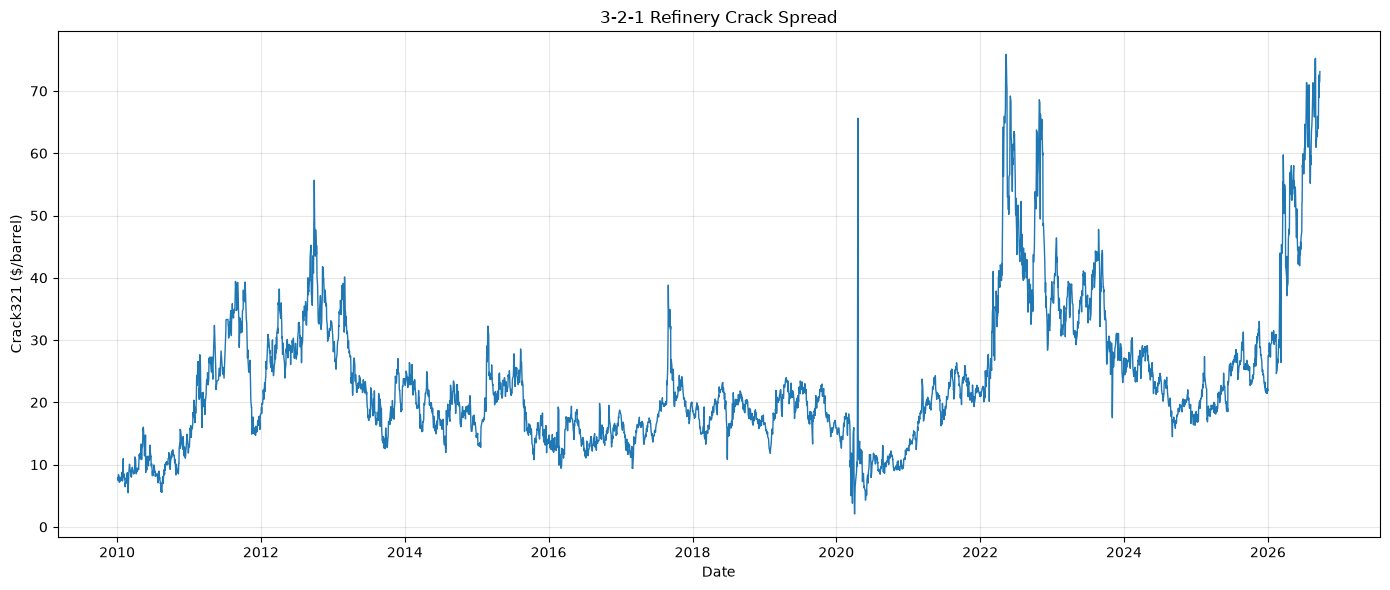

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    data_clean["Date"],
    data_clean["Crack321"],
    linewidth=1
)

plt.title("3-2-1 Refinery Crack Spread")
plt.xlabel("Date")
plt.ylabel("Crack321 ($/barrel)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
top_crack = data_clean[
    [
        "Date",
        "WTI",
        "Gasoline_NY",
        "Diesel_NY",
        "Crack321"
    ]
].sort_values(
    "Crack321",
    ascending=False
)

display(top_crack.head(15))

,Date,WTI,Gasoline_NY,Diesel_NY,Crack321
3044,2022-05-13,110.52,3.988,5.339,75.890
3043,2022-05-12,106.15,3.832,5.327,75.724
4113,2026-08-31,87.03,3.550,4.491,75.244
4112,2026-08-28,84.57,3.527,4.351,75.100
4128,2026-09-22,96.41,3.551,5.007,73.116
3042,2022-05-11,105.50,3.700,5.339,72.846
3041,2022-05-10,99.74,3.558,5.198,72.656
4124,2026-09-16,103.62,3.609,5.365,72.542
4127,2026-09-21,96.97,3.526,4.977,71.436
4126,2026-09-18,101.44,3.593,5.160,71.404


In [37]:
bottom_crack = data_clean[
    [
        "Date",
        "WTI",
        "Gasoline_NY",
        "Diesel_NY",
        "Crack321"
    ]
].sort_values(
    "Crack321",
    ascending=True
)

display(bottom_crack.head(15))

,Date,WTI,Gasoline_NY,Diesel_NY,Crack321
2514,2020-04-03,28.36,0.533,1.108,2.076
2513,2020-04-02,25.18,0.512,1.005,3.226
2505,2020-03-23,23.33,0.449,1.040,3.802
2551,2020-05-28,33.67,0.915,0.882,4.298
2552,2020-05-29,35.57,0.948,0.955,4.344
2500,2020-03-16,28.96,0.692,1.042,5.004
2555,2020-06-03,37.33,1.007,1.015,5.076
35,2010-02-25,77.99,1.952,2.059,5.492
36,2010-02-26,79.72,1.995,2.097,5.498
154,2010-08-16,75.17,1.856,2.053,5.540


In [38]:
data_clean[
    [
        "WTI",
        "Brent",
        "Gasoline_NY",
        "Diesel_NY",
        "JetFuel",
        "Crack321"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
WTI,4129.0,71.965951,20.787032,-36.980,55.560,71.980,88.350,123.640
Brent,4087.0,77.842936,23.977576,9.120,61.050,75.460,98.580,138.210
Gasoline_NY,4129.0,2.208366,0.632326,0.434,1.726,2.143,2.717,4.509
Diesel_NY,4129.0,2.392064,0.779481,0.602,1.881,2.285,2.954,5.365
JetFuel,4129.0,2.261995,0.751292,0.407,1.760,2.142,2.869,5.066
Crack321,4129.0,23.357191,11.633607,2.076,16.110,20.626,27.294,75.890


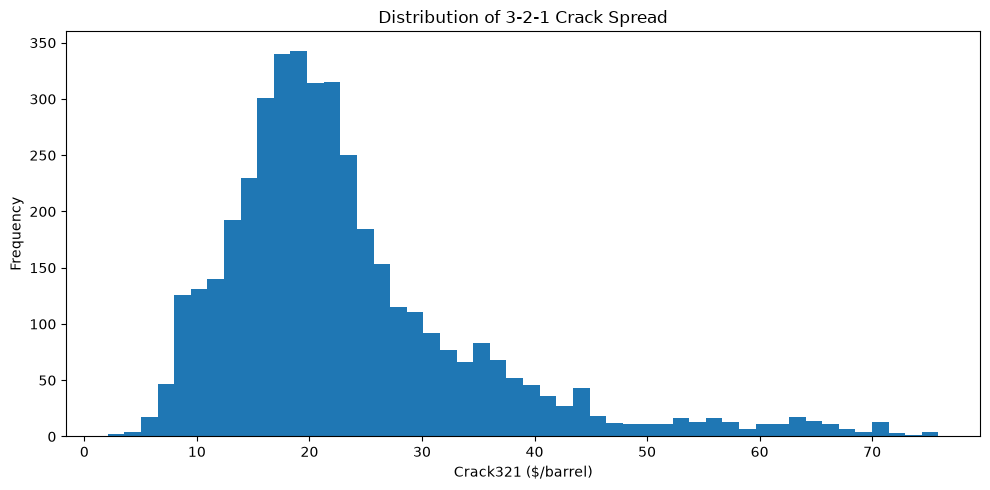

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(
    data_clean["Crack321"],
    bins=50
)

plt.title("Distribution of 3-2-1 Crack Spread")
plt.xlabel("Crack321 ($/barrel)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

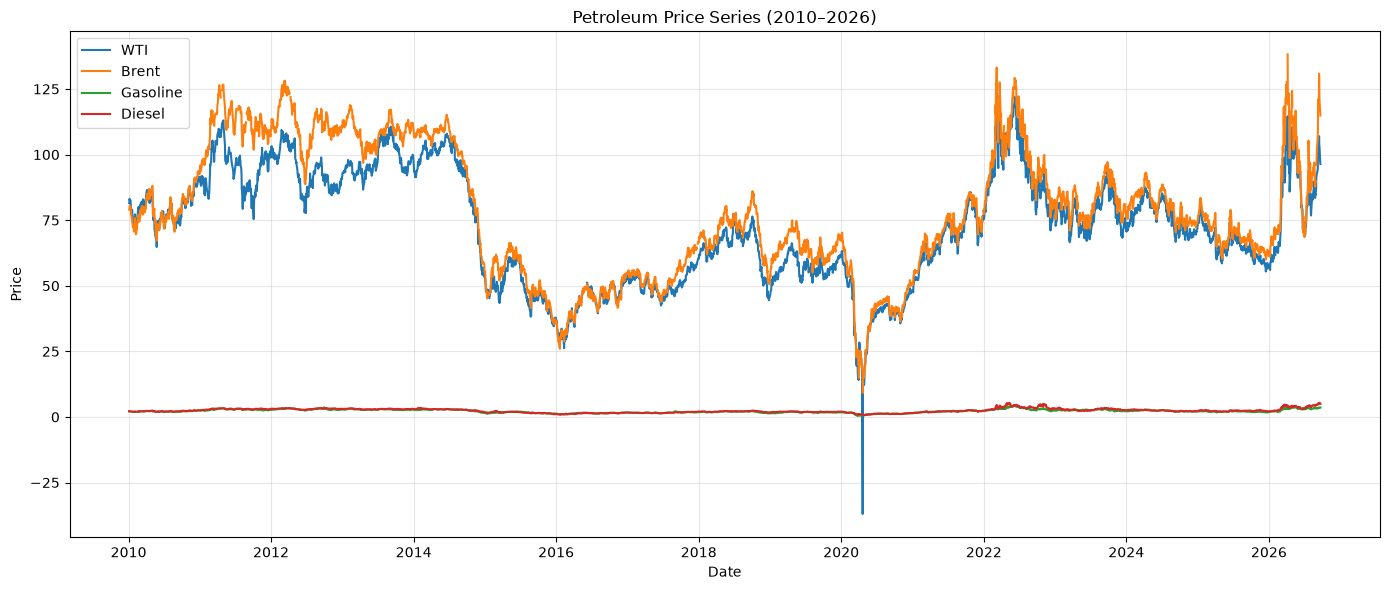

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    data_clean["Date"],
    data_clean["WTI"],
    label="WTI"
)

plt.plot(
    data_clean["Date"],
    data_clean["Brent"],
    label="Brent"
)

plt.plot(
    data_clean["Date"],
    data_clean["Gasoline_NY"],
    label="Gasoline"
)

plt.plot(
    data_clean["Date"],
    data_clean["Diesel_NY"],
    label="Diesel"
)

plt.title("Petroleum Price Series (2010–2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
data_clean["Crack321_30D_Mean"] = (
    data_clean["Crack321"]
    .rolling(30)
    .mean()
)

data_clean["Crack321_30D_STD"] = (
    data_clean["Crack321"]
    .rolling(30)
    .std()
)

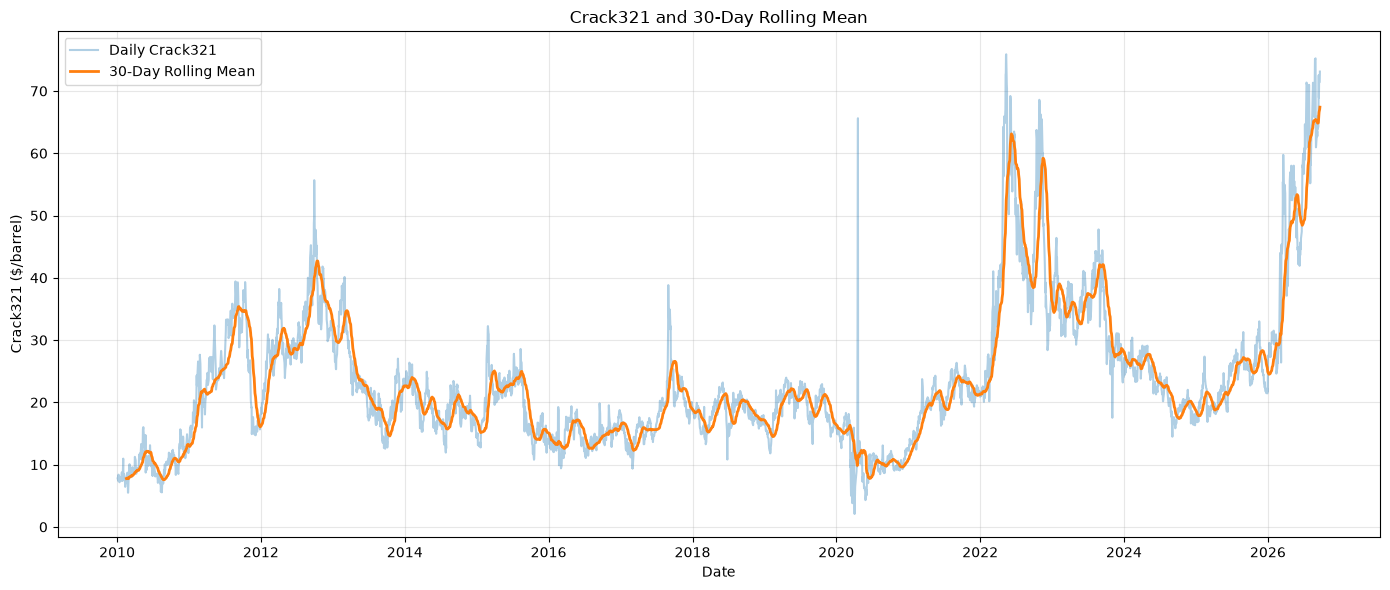

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(
    data_clean["Date"],
    data_clean["Crack321"],
    alpha=0.35,
    label="Daily Crack321"
)

plt.plot(
    data_clean["Date"],
    data_clean["Crack321_30D_Mean"],
    linewidth=2,
    label="30-Day Rolling Mean"
)

plt.title("Crack321 and 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Crack321 ($/barrel)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

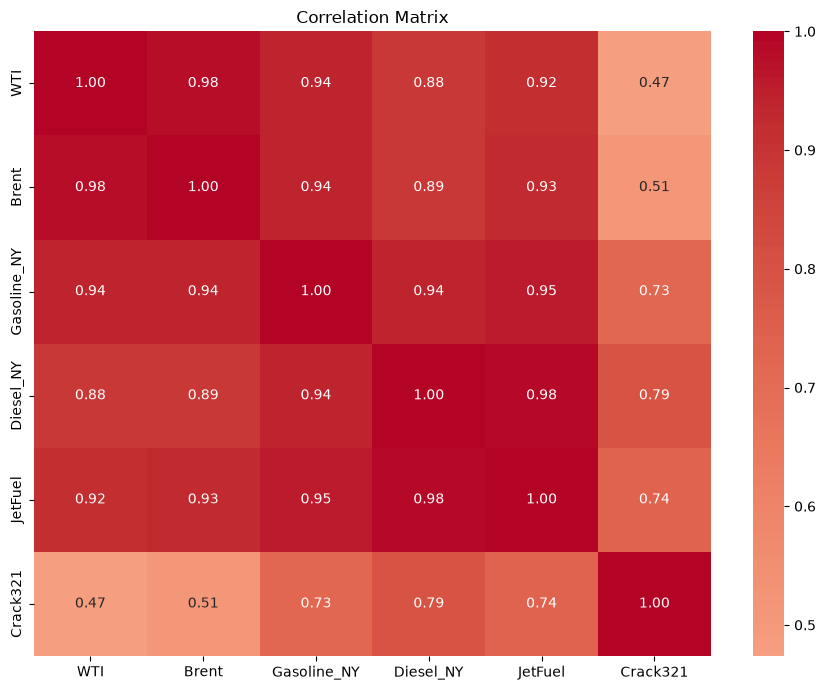

In [43]:
correlation_columns = [
    "WTI",
    "Brent",
    "Gasoline_NY",
    "Diesel_NY",
    "JetFuel",
    "Crack321"
]

correlation_matrix = data_clean[
    correlation_columns
].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [44]:
from statsmodels.tsa.stattools import adfuller

crack_series = data_clean["Crack321"].dropna()

adf_result = adfuller(crack_series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations:", adf_result[3])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.6646186543785224
p-value: 0.08036343118692796
Number of lags used: 4
Number of observations: 4124

Critical Values:
1%: -3.4319366573692
5%: -2.8622410982122712
10%: -2.5671432010511204


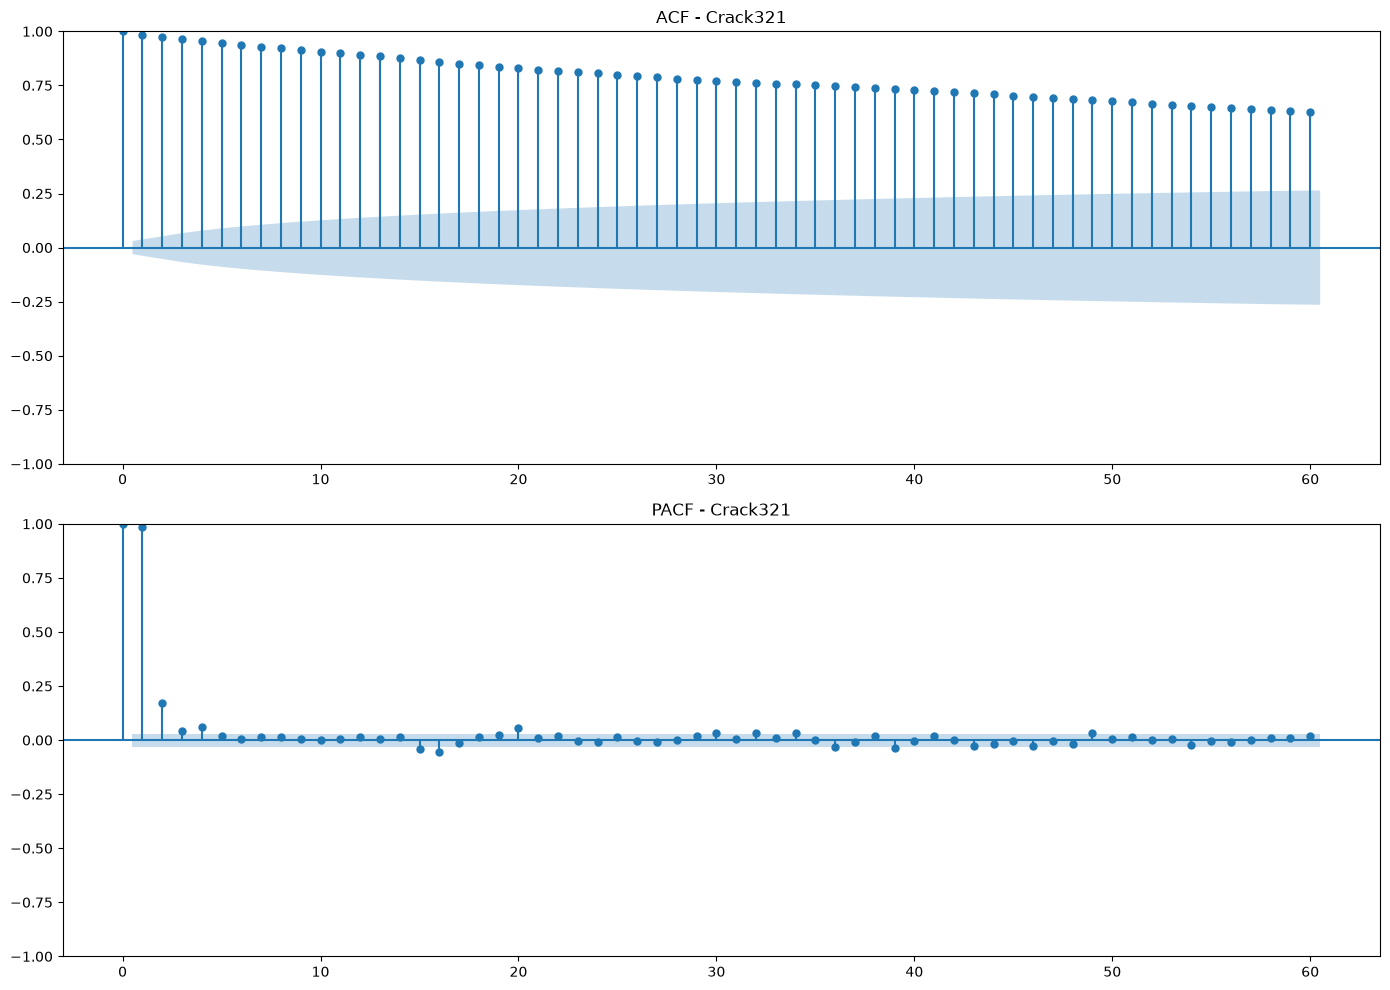

In [45]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(
    crack_series,
    lags=60,
    ax=ax[0]
)

ax[0].set_title("ACF - Crack321")

plot_pacf(
    crack_series,
    lags=60,
    ax=ax[1],
    method="ywm"
)

ax[1].set_title("PACF - Crack321")

plt.tight_layout()
plt.show()

In [46]:
crack_diff = crack_series.diff().dropna()

adf_diff = adfuller(crack_diff)

print("ADF test after first differencing")
print("----------------------------------")
print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

print("\nCritical Values:")

for key, value in adf_diff[4].items():
    print(f"{key}: {value}")

ADF test after first differencing
----------------------------------
ADF Statistic: -16.502018207418267
p-value: 2.1442839755801697e-29

Critical Values:
1%: -3.431943229091185
5%: -2.8622440012896564
10%: -2.5671447465191686


In [47]:
crack_data = data_clean[
    ["Date", "Crack321"]
].copy()

crack_data = crack_data.sort_values(
    "Date"
).reset_index(drop=True)

split_index = int(
    len(crack_data) * 0.80
)

train = crack_data.iloc[
    :split_index
].copy()

test = crack_data.iloc[
    split_index:
].copy()

print("Total observations:", len(crack_data))
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTesting period:")
print(test["Date"].min(), "to", test["Date"].max())

Total observations: 4129
Training observations: 3303
Testing observations: 826

Training period:
2010-01-04 00:00:00 to 2023-05-26 00:00:00

Testing period:
2023-05-30 00:00:00 to 2026-09-22 00:00:00


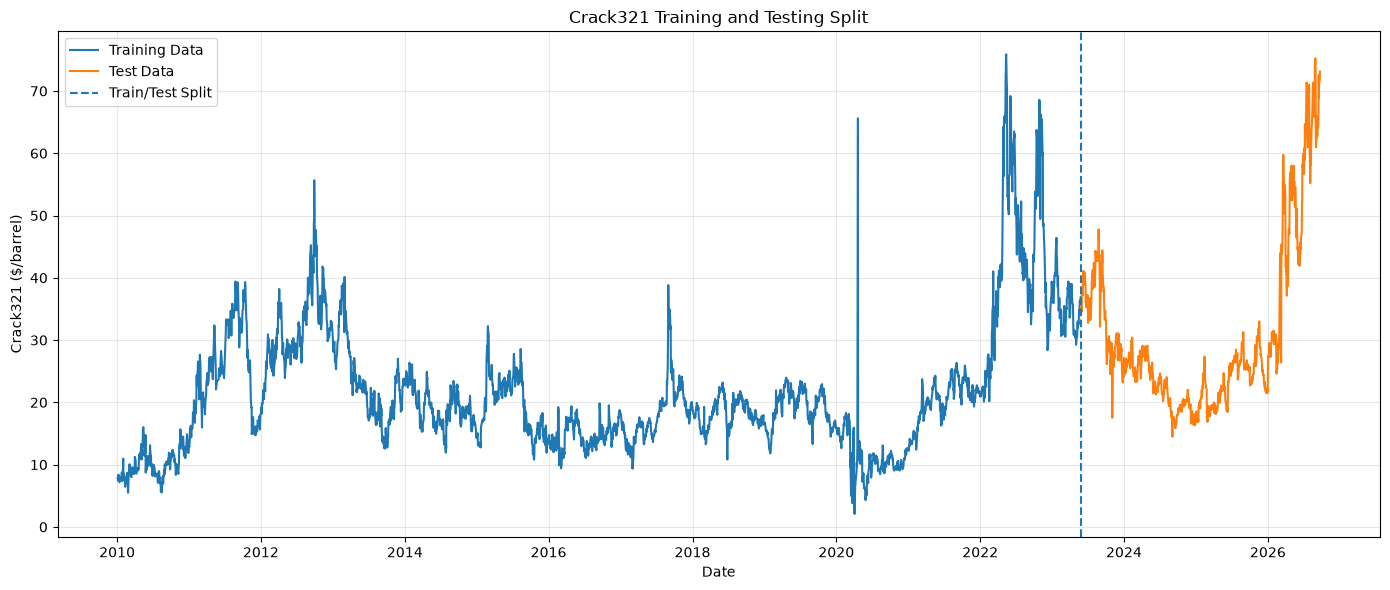

In [48]:
plt.figure(figsize=(14, 6))

plt.plot(
    train["Date"],
    train["Crack321"],
    label="Training Data"
)

plt.plot(
    test["Date"],
    test["Crack321"],
    label="Test Data"
)

plt.axvline(
    test["Date"].iloc[0],
    linestyle="--",
    label="Train/Test Split"
)

plt.title("Crack321 Training and Testing Split")
plt.xlabel("Date")
plt.ylabel("Crack321 ($/barrel)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
test = test.copy()

test["Naive_Forecast"] = (
    train["Crack321"].iloc[-1]
)

for i in range(1, len(test)):
    test.loc[
        test.index[i],
        "Naive_Forecast"
    ] = test["Crack321"].iloc[i - 1]

test.head()

,Date,Crack321,Naive_Forecast
3303,2023-05-30,35.452,36.934
3304,2023-05-31,34.524,35.452
3305,2023-06-01,37.024,34.524
3306,2023-06-02,37.944,37.024
3307,2023-06-05,37.158,37.944


In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

naive_mae = mean_absolute_error(
    test["Crack321"],
    test["Naive_Forecast"]
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test["Crack321"],
        test["Naive_Forecast"]
    )
)

print("Naive Baseline Performance")
print("-" * 35)
print(f"MAE  : {naive_mae:.4f}")
print(f"RMSE : {naive_rmse:.4f}")

Naive Baseline Performance
-----------------------------------
MAE  : 1.1768
RMSE : 1.9060


In [51]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

arima_results = []

train_series = train["Crack321"]

# Test p and q from 0 to 3
for p in range(4):
    for q in range(4):

        order = (p, 1, q)

        try:
            model = ARIMA(
                train_series,
                order=order
            )

            fitted_model = model.fit()

            arima_results.append({
                "Order": order,
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic
            })

            print(
                f"ARIMA{order} → "
                f"AIC: {fitted_model.aic:.2f}, "
                f"BIC: {fitted_model.bic:.2f}"
            )

        except Exception as e:
            print(
                f"ARIMA{order} failed: {e}"
            )

ARIMA(0, 1, 0) → AIC: 13827.90, BIC: 13834.00
ARIMA(0, 1, 1) → AIC: 13629.61, BIC: 13641.81
ARIMA(0, 1, 2) → AIC: 13627.58, BIC: 13645.88
ARIMA(0, 1, 3) → AIC: 13622.39, BIC: 13646.80
ARIMA(1, 1, 0) → AIC: 13650.81, BIC: 13663.01
ARIMA(1, 1, 1) → AIC: 13625.68, BIC: 13643.98
ARIMA(1, 1, 2) → AIC: 13616.21, BIC: 13640.62
ARIMA(1, 1, 3) → AIC: 13624.10, BIC: 13654.61
ARIMA(2, 1, 0) → AIC: 13637.50, BIC: 13655.80
ARIMA(2, 1, 1) → AIC: 13621.87, BIC: 13646.27
ARIMA(2, 1, 2) → AIC: 13623.70, BIC: 13654.21
ARIMA(2, 1, 3) → AIC: 13625.63, BIC: 13662.24
ARIMA(3, 1, 0) → AIC: 13626.93, BIC: 13651.34
ARIMA(3, 1, 1) → AIC: 13623.77, BIC: 13654.28
ARIMA(3, 1, 2) → AIC: 13625.86, BIC: 13662.47
ARIMA(3, 1, 3) → AIC: 13627.03, BIC: 13669.75


In [52]:
arima_results_df = pd.DataFrame(
    arima_results
)

arima_results_df = arima_results_df.sort_values(
    "AIC"
).reset_index(drop=True)

display(arima_results_df)

,Order,AIC,BIC
0,"(1, 1, 2)",13616.207631,13640.616765
1,"(2, 1, 1)",13621.865226,13646.274360
2,"(0, 1, 3)",13622.393862,13646.802996
3,"(2, 1, 2)",13623.695464,13654.206882
4,"(3, 1, 1)",13623.772291,13654.283709
5,"(1, 1, 3)",13624.096093,13654.607511
6,"(2, 1, 3)",13625.628161,13662.241863
7,"(1, 1, 1)",13625.675543,13643.982393
8,"(3, 1, 2)",13625.858611,13662.472313
9,"(3, 1, 0)",13626.933409,13651.342543


In [53]:
best_order = arima_results_df.iloc[0]["Order"]

print("Best ARIMA order based on AIC:")
print(best_order)

Best ARIMA order based on AIC:
(1, 1, 2)


In [54]:
best_arima = ARIMA(
    train_series,
    order=best_order
).fit()

print(best_arima.summary())

                               SARIMAX Results                                
Dep. Variable:               Crack321   No. Observations:                 3303
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -6804.104
Date:                Wed, 30 Sep 2026   AIC                          13616.208
Time:                        23:51:23   BIC                          13640.617
Sample:                             0   HQIC                         13624.945
                               - 3303                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9622      0.010     97.178      0.000       0.943       0.982
ma.L1         -1.2217      0.011   -115.987      0.000      -1.242      -1.201
ma.L2          0.2349      0.006     41.615      0.0

In [55]:
arima_forecast = best_arima.forecast(
    steps=len(test)
)

arima_forecast = np.asarray(
    arima_forecast
)

print("Number of ARIMA forecasts:", len(arima_forecast))

print("\nFirst 10 forecasts:")
print(arima_forecast[:10])

Number of ARIMA forecasts: 826

First 10 forecasts:
[36.777809   36.76673241 36.75607471 36.74582006 36.73595323 36.72645955
 36.7173249  36.70853571 36.70007891 36.69194194]


In [56]:
arima_mae = mean_absolute_error(
    test["Crack321"],
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test["Crack321"],
        arima_forecast
    )
)

print("ARIMA Test Performance")
print("-" * 35)
print(f"Model: ARIMA{best_order}")
print(f"MAE  : {arima_mae:.4f}")
print(f"RMSE : {arima_rmse:.4f}")

ARIMA Test Performance
-----------------------------------
Model: ARIMA(1, 1, 2)
MAE  : 12.7376
RMSE : 14.4017


In [57]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        f"ARIMA{best_order}"
    ],
    "MAE": [
        naive_mae,
        arima_mae
    ],
    "RMSE": [
        naive_rmse,
        arima_rmse
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Naive Baseline,1.176835,1.905956
1,"ARIMA(1, 1, 2)",12.737592,14.401690


In [58]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

arima_order = (1, 1, 2)

history = list(train["Crack321"])

rolling_forecasts = []

for i in range(len(test)):
    
    model = ARIMA(
        history,
        order=arima_order
    )
    
    fitted_model = model.fit()
    
    forecast = fitted_model.forecast(
        steps=1
    )[0]
    
    rolling_forecasts.append(forecast)
    
    # Add the actual observed value
    history.append(
        test["Crack321"].iloc[i]
    )

print("Rolling forecasts generated:", len(rolling_forecasts))

Rolling forecasts generated: 826


In [59]:
rolling_arima_mae = mean_absolute_error(
    test["Crack321"],
    rolling_forecasts
)

rolling_arima_rmse = np.sqrt(
    mean_squared_error(
        test["Crack321"],
        rolling_forecasts
    )
)

print("Rolling ARIMA(1,1,2) Performance")
print("-" * 40)
print(f"MAE  : {rolling_arima_mae:.4f}")
print(f"RMSE : {rolling_arima_rmse:.4f}")

Rolling ARIMA(1,1,2) Performance
----------------------------------------
MAE  : 4.0906
RMSE : 83.2741


In [60]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "ARIMA(1,1,2) - Long Horizon",
        "ARIMA(1,1,2) - Rolling"
    ],
    "MAE": [
        naive_mae,
        arima_mae,
        rolling_arima_mae
    ],
    "RMSE": [
        naive_rmse,
        arima_rmse,
        rolling_arima_rmse
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Naive Baseline,1.176835,1.905956
1,"ARIMA(1,1,2) - Long Horizon",12.737592,14.401690
2,"ARIMA(1,1,2) - Rolling",4.090605,83.274131


In [61]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

arima_order = (1, 1, 2)

history = list(train["Crack321"])

rolling_forecasts = []

refit_interval = 20

# Initial model fit
model = ARIMA(
    history,
    order=arima_order
)

fitted_model = model.fit()

for i in range(len(test)):

    # Forecast the next observation
    forecast = fitted_model.forecast(steps=1)[0]

    rolling_forecasts.append(forecast)

    # Actual observation
    actual_value = test["Crack321"].iloc[i]

    # Update model with the newly observed value
    fitted_model = fitted_model.append(
        [actual_value],
        refit=False
    )

    # Occasionally refit model parameters
    if (i + 1) % refit_interval == 0:

        model = ARIMA(
            history + list(
                test["Crack321"].iloc[:i + 1]
            ),
            order=arima_order
        )

        fitted_model = model.fit()

print(
    "Proper rolling forecasts generated:",
    len(rolling_forecasts)
)

Proper rolling forecasts generated: 826


In [62]:
rolling_arima_mae = mean_absolute_error(
    test["Crack321"],
    rolling_forecasts
)

rolling_arima_rmse = np.sqrt(
    mean_squared_error(
        test["Crack321"],
        rolling_forecasts
    )
)

print("Proper Rolling ARIMA(1,1,2)")
print("-" * 40)
print(f"MAE  : {rolling_arima_mae:.4f}")
print(f"RMSE : {rolling_arima_rmse:.4f}")

Proper Rolling ARIMA(1,1,2)
----------------------------------------
MAE  : 1.1960
RMSE : 1.9117


In [63]:
forecast_check = pd.DataFrame({
    "Date": test["Date"].values,
    "Actual": test["Crack321"].values,
    "Forecast": rolling_forecasts
})

forecast_check["Error"] = (
    forecast_check["Actual"]
    - forecast_check["Forecast"]
)

forecast_check["Absolute_Error"] = (
    forecast_check["Error"].abs()
)

display(
    forecast_check.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(10)
)

,Date,Actual,Forecast,Error,Absolute_Error
689,2026-03-09,26.394,38.777744,-12.383744,12.383744
690,2026-03-10,40.694,29.313114,11.380886,11.380886
811,2026-09-01,64.340,74.657482,-10.317482,10.317482
108,2023-11-02,18.292,28.176286,-9.884286,9.884286
110,2023-11-06,28.066,18.618964,9.447036,9.447036
684,2026-03-02,37.804,28.929139,8.874861,8.874861
706,2026-04-01,41.768,50.157274,-8.389274,8.389274
66,2023-09-01,32.164,40.136626,-7.972626,7.972626
696,2026-03-18,55.416,47.554680,7.861320,7.861320
698,2026-03-20,59.742,51.996077,7.745923,7.745923


In [64]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "ARIMA(1,1,2) - Long Horizon",
        "ARIMA(1,1,2) - Proper Rolling"
    ],
    "MAE": [
        naive_mae,
        arima_mae,
        rolling_arima_mae
    ],
    "RMSE": [
        naive_rmse,
        arima_rmse,
        rolling_arima_rmse
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Naive Baseline,1.176835,1.905956
1,"ARIMA(1,1,2) - Long Horizon",12.737592,14.401690
2,"ARIMA(1,1,2) - Proper Rolling",1.196047,1.911728


In [65]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import warnings

warnings.filterwarnings("ignore")

candidate_orders = [
    (0, 1, 0),
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 0),
    (2, 1, 1),
    (2, 1, 2)
]

arima_comparison = []

for order in candidate_orders:

    print(f"Testing ARIMA{order}...")

    history = list(train["Crack321"])
    forecasts = []

    model = ARIMA(
        history,
        order=order
    )

    fitted_model = model.fit()

    for i in range(len(test)):

        forecast = fitted_model.forecast(
            steps=1
        )[0]

        forecasts.append(
            forecast
        )

        actual_value = test[
            "Crack321"
        ].iloc[i]

        fitted_model = fitted_model.append(
            [actual_value],
            refit=False
        )

        if (i + 1) % 20 == 0:

            current_history = (
                history
                +
                list(
                    test[
                        "Crack321"
                    ].iloc[:i + 1]
                )
            )

            model = ARIMA(
                current_history,
                order=order
            )

            fitted_model = model.fit()

    mae = mean_absolute_error(
        test["Crack321"],
        forecasts
    )

    rmse = np.sqrt(
        mean_squared_error(
            test["Crack321"],
            forecasts
        )
    )

    arima_comparison.append({
        "Model": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse
    })

    print(
        f"MAE={mae:.4f}, "
        f"RMSE={rmse:.4f}"
    )

Testing ARIMA(0, 1, 0)...
MAE=1.1768, RMSE=1.9060
Testing ARIMA(0, 1, 1)...
MAE=1.1946, RMSE=1.9175
Testing ARIMA(1, 1, 0)...
MAE=1.1887, RMSE=1.9160
Testing ARIMA(1, 1, 1)...
MAE=1.1984, RMSE=1.9105
Testing ARIMA(1, 1, 2)...
MAE=1.1960, RMSE=1.9117
Testing ARIMA(2, 1, 0)...
MAE=1.1940, RMSE=1.9174
Testing ARIMA(2, 1, 1)...
MAE=1.1950, RMSE=1.9189
Testing ARIMA(2, 1, 2)...
MAE=1.1953, RMSE=1.9091


In [67]:
arima_comparison_df = pd.DataFrame(
    arima_comparison
).sort_values(
    "MAE"
).reset_index(drop=True)

display(arima_comparison_df)

,Model,MAE,RMSE
0,"ARIMA(0, 1, 0)",1.176835,1.905956
1,"ARIMA(1, 1, 0)",1.188680,1.916037
2,"ARIMA(2, 1, 0)",1.194035,1.917442
3,"ARIMA(0, 1, 1)",1.194605,1.917463
4,"ARIMA(2, 1, 1)",1.194975,1.918936
5,"ARIMA(2, 1, 2)",1.195337,1.909097
6,"ARIMA(1, 1, 2)",1.196047,1.911728
7,"ARIMA(1, 1, 1)",1.198365,1.910530


In [68]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Final ARIMA model
order = (0, 1, 0)

history = list(train["Crack321"])
forecasts = []

model = ARIMA(history, order=order)
fitted_model = model.fit()

for i in range(len(test)):
    # One-step-ahead forecast
    forecast = fitted_model.forecast(steps=1)[0]
    forecasts.append(forecast)

    # Add actual observation
    actual_value = test["Crack321"].iloc[i]
    fitted_model = fitted_model.append(
        [actual_value],
        refit=False
    )

# Store predictions
arima_best_forecast = test.copy()
arima_best_forecast["ARIMA_Forecast"] = forecasts

# Metrics
mae = mean_absolute_error(
    arima_best_forecast["Crack321"],
    arima_best_forecast["ARIMA_Forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        arima_best_forecast["Crack321"],
        arima_best_forecast["ARIMA_Forecast"]
    )
)

print("Final ARIMA(0,1,0) Performance")
print("-" * 40)
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")

Final ARIMA(0,1,0) Performance
----------------------------------------
MAE  : 1.176835
RMSE : 1.905956


In [69]:
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [70]:
# Prepare data for Prophet

prophet_train = train[["Date", "Crack321"]].copy()

prophet_train = prophet_train.rename(columns={
    "Date": "ds",
    "Crack321": "y"
})

prophet_train.head()

,ds,y
0,2010-01-04,7.786
1,2010-01-05,7.986
2,2010-01-06,7.404
3,2010-01-07,7.420
4,2010-01-08,8.386


In [71]:
# Create and train Prophet model

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

00:09:50 - cmdstanpy - INFO - Chain [1] start processing
00:09:51 - cmdstanpy - INFO - Chain [1] done processing


In [72]:
# Create future dates for the test period

future = test[["Date"]].copy()
future = future.rename(columns={"Date": "ds"})

future.head()

,ds
3303,2023-05-30
3304,2023-05-31
3305,2023-06-01
3306,2023-06-02
3307,2023-06-05


In [73]:
# Generate Prophet forecasts

prophet_forecast = prophet_model.predict(future)

prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2023-05-30,49.887842,42.587657,57.061130
1,2023-05-31,49.912813,41.535263,57.024227
2,2023-06-01,50.047621,42.362473,57.390431
3,2023-06-02,50.160601,42.344043,57.899412
4,2023-06-05,50.198568,43.587480,57.810820


In [74]:
# Calculate Prophet performance

prophet_predictions = prophet_forecast[["ds", "yhat"]].copy()

prophet_predictions = prophet_predictions.rename(
    columns={"ds": "Date", "yhat": "Prophet_Forecast"}
)

# Merge actual values with Prophet forecasts
prophet_results = test[["Date", "Crack321"]].merge(
    prophet_predictions,
    on="Date",
    how="inner"
)

# Calculate metrics
prophet_mae = mean_absolute_error(
    prophet_results["Crack321"],
    prophet_results["Prophet_Forecast"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_results["Crack321"],
        prophet_results["Prophet_Forecast"]
    )
)

print("Prophet Test Performance")
print("-" * 40)
print(f"MAE  : {prophet_mae:.6f}")
print(f"RMSE : {prophet_rmse:.6f}")

Prophet Test Performance
----------------------------------------
MAE  : 40.736137
RMSE : 43.111228


In [75]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Use the same rolling test setup as ARIMA
prophet_rolling_forecasts = []

history = train[["Date", "Crack321"]].copy()

for i in range(len(test)):
    
    # Prepare training data available at this point
    prophet_train_current = history.rename(
        columns={
            "Date": "ds",
            "Crack321": "y"*/***
        }
    )
    
    # Create Prophet model
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True
    )
    
    # Fit model
    model.fit(prophet_train_current)
    
    # Forecast the next test date
    next_date = test["Date"].iloc[i]
    
    future = pd.DataFrame({
        "ds": [next_date]
    })
    
    forecast = model.predict(future)
    
    predicted_value = forecast["yhat"].iloc[0]
    
    prophet_rolling_forecasts.append(predicted_value)
    
    # Add actual test observation to history
    new_row = pd.DataFrame({
        "Date": [next_date],
        "Crack321": [test["Crack321"].iloc[i]]
    })
    
    history = pd.concat(
        [history, new_row],
        ignore_index=True
    )

print("Rolling Prophet forecasting completed.")

00:12:21 - cmdstanpy - INFO - Chain [1] start processing
00:12:22 - cmdstanpy - INFO - Chain [1] done processing
00:12:22 - cmdstanpy - INFO - Chain [1] start processing
00:12:23 - cmdstanpy - INFO - Chain [1] done processing
00:12:24 - cmdstanpy - INFO - Chain [1] start processing
00:12:24 - cmdstanpy - INFO - Chain [1] done processing
00:12:24 - cmdstanpy - INFO - Chain [1] start processing
00:12:25 - cmdstanpy - INFO - Chain [1] done processing
00:12:26 - cmdstanpy - INFO - Chain [1] start processing
00:12:26 - cmdstanpy - INFO - Chain [1] done processing
00:12:27 - cmdstanpy - INFO - Chain [1] start processing
00:12:28 - cmdstanpy - INFO - Chain [1] done processing
00:12:28 - cmdstanpy - INFO - Chain [1] start processing
00:12:29 - cmdstanpy - INFO - Chain [1] done processing
00:12:29 - cmdstanpy - INFO - Chain [1] start processing
00:12:30 - cmdstanpy - INFO - Chain [1] done processing
00:12:30 - cmdstanpy - INFO - Chain [1] start processing
00:12:31 - cmdstanpy - INFO - Chain [1]

Rolling Prophet forecasting completed.


In [76]:
prophet_rolling_mae = mean_absolute_error(
    test["Crack321"],
    prophet_rolling_forecasts
)

prophet_rolling_rmse = np.sqrt(
    mean_squared_error(
        test["Crack321"],
        prophet_rolling_forecasts
    )
)

print("Prophet Rolling Test Performance")
print("-" * 45)
print(f"MAE  : {prophet_rolling_mae:.6f}")
print(f"RMSE : {prophet_rolling_rmse:.6f}")

Prophet Rolling Test Performance
---------------------------------------------
MAE  : 13.582541
RMSE : 16.168133


In [77]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# Extract Crack321 values
train_values = train["Crack321"].values.reshape(-1, 1)
test_values = test["Crack321"].values.reshape(-1, 1)

# Fit scaler ONLY on training data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_values)

# Transform test data using the same scaler
test_scaled = scaler.transform(test_values)

print("Training samples:", len(train_scaled))
print("Testing samples :", len(test_scaled))
print("Scaled train range:", train_scaled.min(), "to", train_scaled.max())

Training samples: 3303
Testing samples : 826
Scaled train range: 0.0 to 1.0


In [78]:
# Create sequences for LSTM

lookback = 30

X_train = []
y_train = []

for i in range(lookback, len(train_scaled)):
    X_train.append(train_scaled[i-lookback:i, 0])
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape for LSTM:
# samples, timesteps, features
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (3273, 30, 1)
y_train shape: (3273,)


In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 1)),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# Train LSTM

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0049 - val_loss: 0.0301
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - val_loss: 0.0106
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019 - val_loss: 0.0060
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0021 - val_loss: 0.0101
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 0.0072
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015 - val_loss: 0.0086
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - val_loss: 0.0078
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012 - val_loss: 0.0086
Epoch 9/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 0.0105
Epoch 10/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0097
Epoch 11/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 0.0120
Epoch 12/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.5

In [81]:
# Prepare test sequences for LSTM

# Combine the last 30 training observations with the test observations
combined_values = np.concatenate([
    train_values[-lookback:],
    test_values
])

# Scale using the scaler fitted on training data
combined_scaled = scaler.transform(combined_values)

X_test = []

for i in range(lookback, len(combined_scaled)):
    X_test.append(combined_scaled[i-lookback:i, 0])

X_test = np.array(X_test)

# Reshape for LSTM
X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_test shape:", X_test.shape)
print("Expected test samples:", len(test))

X_test shape: (826, 30, 1)
Expected test samples: 826


In [82]:
# Generate LSTM predictions

lstm_predictions_scaled = lstm_model.predict(
    X_test,
    verbose=1
)

# Convert predictions back to original Crack321 scale
lstm_predictions = scaler.inverse_transform(
    lstm_predictions_scaled
).flatten()

print("Number of predictions:", len(lstm_predictions))
print("First 5 predictions:", lstm_predictions[:5])

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Number of predictions: 826
First 5 predictions: [34.216324 33.754704 33.062267 33.747925 34.681126]


In [83]:
# Calculate LSTM performance

lstm_mae = mean_absolute_error(
    test["Crack321"],
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        test["Crack321"],
        lstm_predictions
    )
)

print("LSTM Test Performance")
print("-" * 40)
print(f"MAE  : {lstm_mae:.6f}")
print(f"RMSE : {lstm_rmse:.6f}")

LSTM Test Performance
----------------------------------------
MAE  : 2.775591
RMSE : 4.574660


In [84]:
# Final model comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "ARIMA(0,1,0)",
        "Prophet",
        "LSTM"
    ],
    "MAE": [
        1.176835,
        1.176835,
        13.582541,
        2.775591
    ],
    "RMSE": [
        1.905956,
        1.905956,
        16.168133,
        4.574660
    ]
})

display(final_comparison)

,Model,MAE,RMSE
0,Naive Baseline,1.176835,1.905956
1,"ARIMA(0,1,0)",1.176835,1.905956
2,Prophet,13.582541,16.168133
3,LSTM,2.775591,4.574660


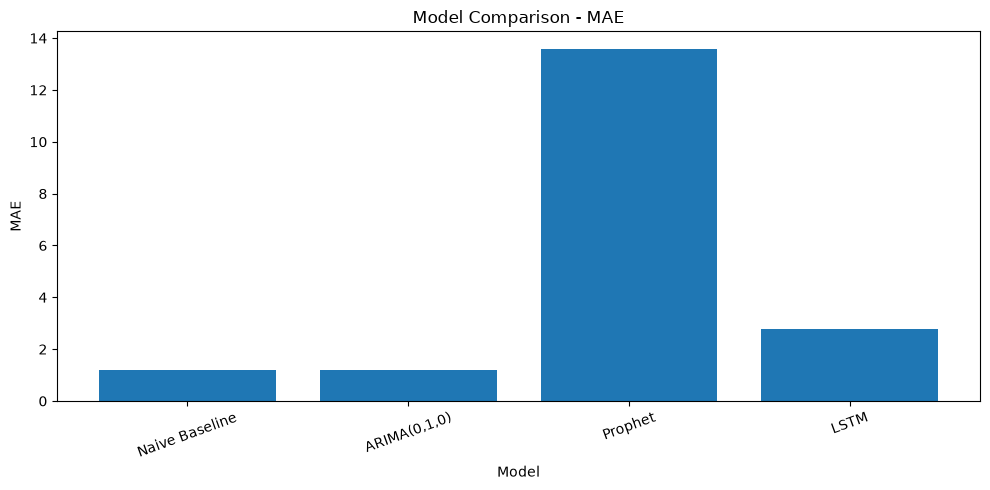

In [85]:
# Plot MAE comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [86]:
# Create final prediction comparison

prediction_comparison = test[["Date", "Crack321"]].copy()

prediction_comparison["Naive"] = test["Naive_Forecast"].values
prediction_comparison["ARIMA"] = arima_best_forecast["ARIMA_Forecast"].values
prediction_comparison["Prophet"] = prophet_rolling_forecasts
prediction_comparison["LSTM"] = lstm_predictions

prediction_comparison.head()

,Date,Crack321,Naive,ARIMA,Prophet,LSTM
3303,2023-05-30,35.452,36.934,36.934,49.887842,34.216324
3304,2023-05-31,34.524,35.452,35.452,49.691633,33.754704
3305,2023-06-01,37.024,34.524,34.524,49.696128,33.062267
3306,2023-06-02,37.944,37.024,37.024,49.548536,33.747925
3307,2023-06-05,37.158,37.944,37.944,49.344981,34.681126


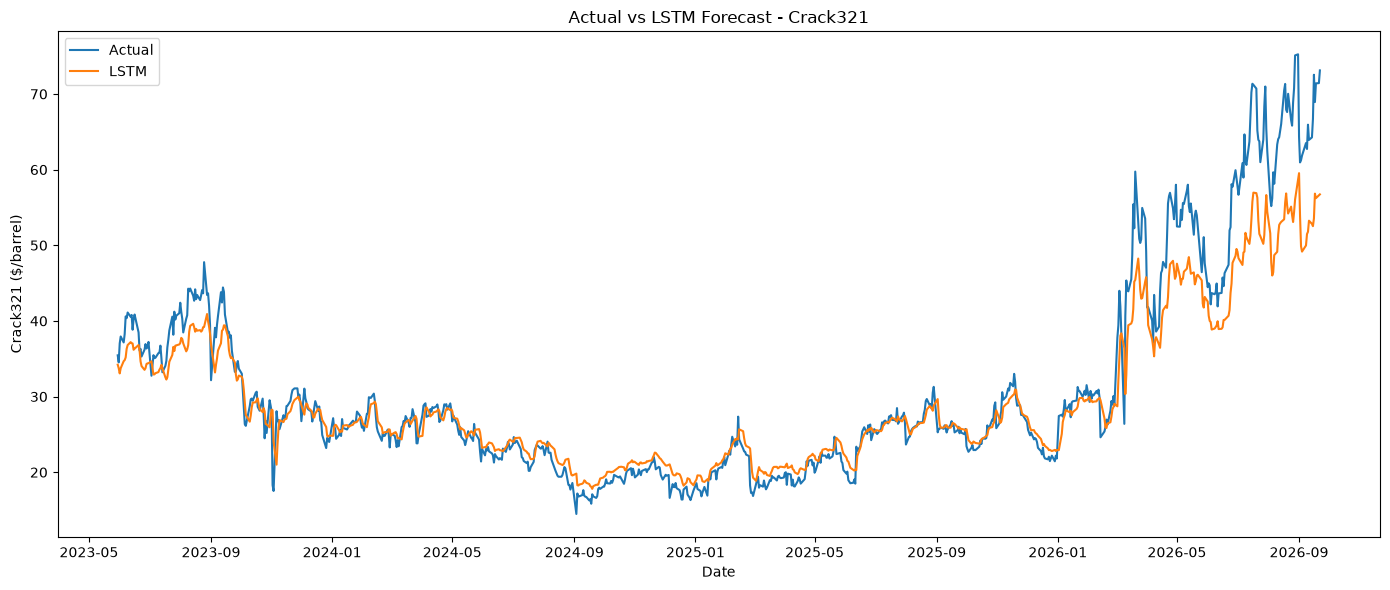

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    prediction_comparison["Date"],
    prediction_comparison["Crack321"],
    label="Actual"
)

plt.plot(
    prediction_comparison["Date"],
    prediction_comparison["LSTM"],
    label="LSTM"
)

plt.title("Actual vs LSTM Forecast - Crack321")
plt.xlabel("Date")
plt.ylabel("Crack321 ($/barrel)")
plt.legend()
plt.tight_layout()
plt.show()

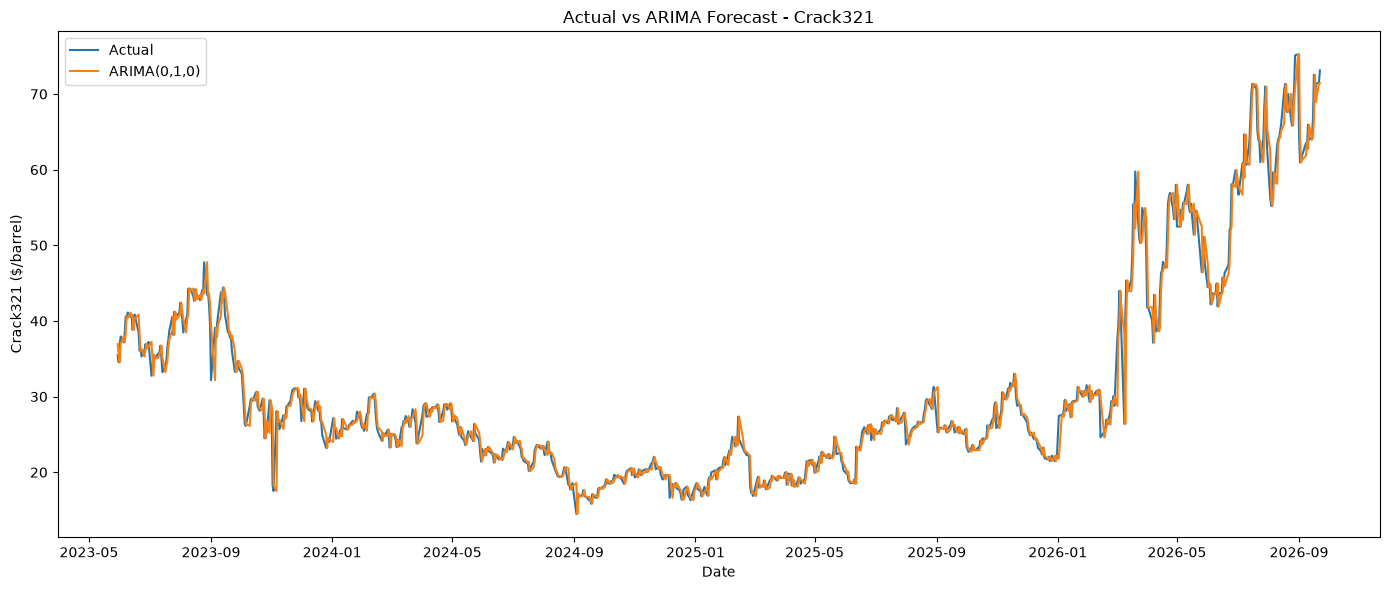

In [88]:
plt.figure(figsize=(14, 6))

plt.plot(
    prediction_comparison["Date"],
    prediction_comparison["Crack321"],
    label="Actual"
)

plt.plot(
    prediction_comparison["Date"],
    prediction_comparison["ARIMA"],
    label="ARIMA(0,1,0)"
)

plt.title("Actual vs ARIMA Forecast - Crack321")
plt.xlabel("Date")
plt.ylabel("Crack321 ($/barrel)")
plt.legend()
plt.tight_layout()
plt.show()

In [89]:
# Final ARIMA model using all available Crack321 observations

full_crack_data = data_clean[["Date", "Crack321"]].copy()

full_crack_data = (
    full_crack_data
    .sort_values("Date")
    .reset_index(drop=True)
)

full_history = full_crack_data["Crack321"].tolist()

final_arima_model = ARIMA(
    full_history,
    order=(0, 1, 0)
)

final_arima_fitted = final_arima_model.fit()

print("Final ARIMA(0,1,0) trained on all available data.")
print("Last observed date:", full_crack_data["Date"].iloc[-1])
print("Last observed Crack321:", full_crack_data["Crack321"].iloc[-1])

Final ARIMA(0,1,0) trained on all available data.
Last observed date: 2026-09-22 00:00:00
Last observed Crack321: 73.11599999999999


In [91]:
# Forecast the next 30 business days

forecast_steps = 30

future_forecast = final_arima_fitted.get_forecast(
    steps=forecast_steps
)

forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int()

# Create future business-day dates
future_dates = pd.bdate_range(
    start=full_crack_data["Date"].iloc[-1] + pd.Timedelta(days=1),
    periods=forecast_steps
)

future_results = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast_mean,
    "Lower_CI": forecast_ci[:, 0],
    "Upper_CI": forecast_ci[:, 1]
})

display(future_results)

,Date,Forecast,Lower_CI,Upper_CI
0,2026-09-23,73.116,69.290242,76.941758
1,2026-09-24,73.116,67.705561,78.526439
2,2026-09-25,73.116,66.489593,79.742407
3,2026-09-28,73.116,65.464484,80.767516
4,2026-09-29,73.116,64.561345,81.670655
5,2026-09-30,73.116,63.744845,82.487155
6,2026-10-01,73.116,62.993996,83.238004
7,2026-10-02,73.116,62.295123,83.936877
8,2026-10-05,73.116,61.638726,84.593274
9,2026-10-06,73.116,61.017891,85.214109


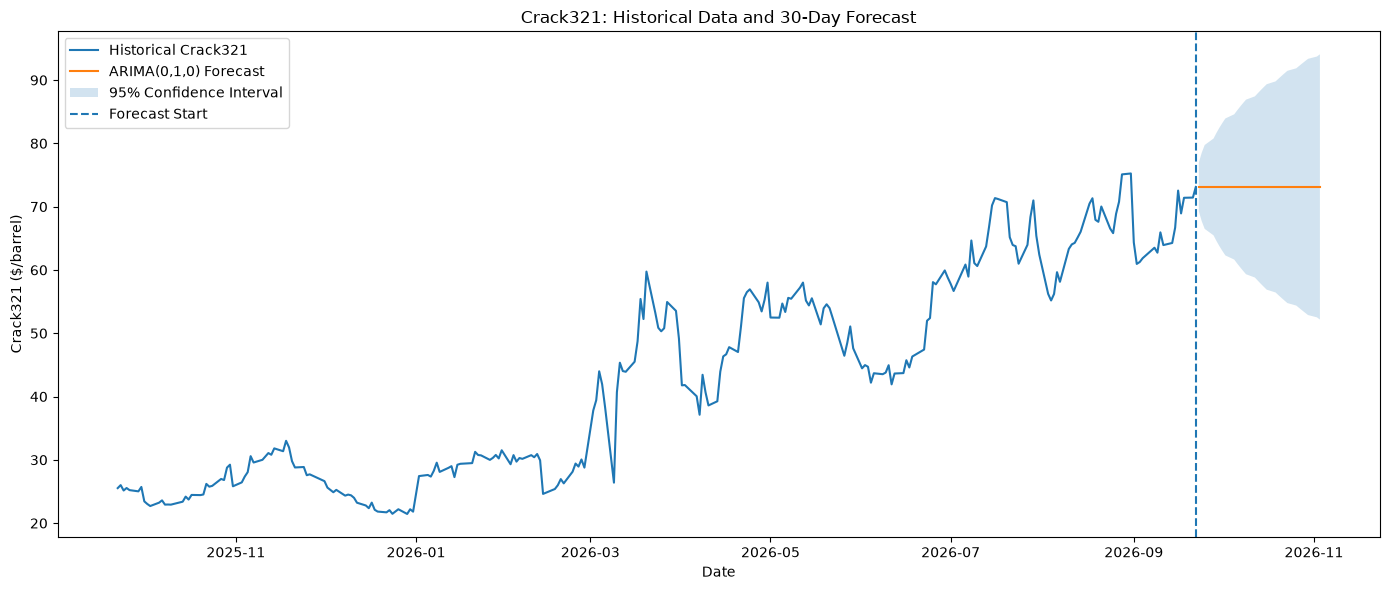

In [92]:
# Plot historical data and future forecast

plt.figure(figsize=(14, 6))

# Last 250 historical observations for readability
recent_history = full_crack_data.tail(250)

plt.plot(
    recent_history["Date"],
    recent_history["Crack321"],
    label="Historical Crack321"
)

# Future forecast
plt.plot(
    future_results["Date"],
    future_results["Forecast"],
    label="ARIMA(0,1,0) Forecast"
)

# Confidence interval
plt.fill_between(
    future_results["Date"],
    future_results["Lower_CI"],
    future_results["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(
    full_crack_data["Date"].iloc[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title("Crack321: Historical Data and 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Crack321 ($/barrel)")
plt.legend()
plt.tight_layout()
plt.show()

In [93]:
# Save final project results

final_comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

prediction_comparison.to_csv(
    "../results/test_predictions.csv",
    index=False
)

future_results.to_csv(
    "../results/future_forecast.csv",
    index=False
)

print("All result files saved successfully.")

All result files saved successfully.


In [94]:
import pickle
import os

# Save final ARIMA model
model_path = "../models/final_arima_model.pkl"

with open(model_path, "wb") as file:
    pickle.dump(final_arima_fitted, file)

print("Final ARIMA model saved successfully.")
print("Location:", os.path.abspath(model_path))

Final ARIMA model saved successfully.
Location: D:\Crude_Oil_Forcasting_Model\models\final_arima_model.pkl
